# 1. Email Spam Detection using TF-IDF + Logistic Regression
# Task: Classify emails as spam or ham using TF-IDF and logistic regression.

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report

emails = [
    ("Win a FREE trip now!", "spam"),
    ("Please review the attached report", "ham"),
    ("Congratulations, you have won a lottery!", "spam"),
    ("Meeting scheduled at 10 AM tomorrow", "ham"),
    ("Free coupons waiting for you", "spam")
]

texts, labels = zip(*emails)

model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(solver="liblinear"))
])

scores = cross_val_score(model, texts, labels, cv=3)
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

model.fit(texts, labels)

y_pred = model.predict(texts)
print("\nClassification Report (on training set):")
print(classification_report(labels, y_pred))

new_emails = [
    "Claim your free prize now!",
    "Let's catch up for lunch tomorrow",
    "Exclusive offer: buy one get one free"
]
print("\nPredictions for new emails:")
for email, pred in zip(new_emails, model.predict(new_emails)):
    print(f"'{email}' → {pred}")

Cross-validation scores: [0.5 0.5 1. ]
Mean accuracy: 0.6666666666666666

Classification Report (on training set):
              precision    recall  f1-score   support

         ham       1.00      1.00      1.00         2
        spam       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


Predictions for new emails:
'Claim your free prize now!' → spam
'Let's catch up for lunch tomorrow' → spam
'Exclusive offer: buy one get one free' → spam


C:\Users\kalas\anaconda3\envs\aiml\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


# 2. News Classification using CountVectorizer
# Task: Classify news into politics or sports.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

news_data = [
    ("The prime minister addressed the nation.", "politics"),
    ("The team won the cricket match yesterday.", "sports"),
    ("New laws were introduced in the parliament.", "politics"),
    ("Football tournament starts next week.", "sports"),
    ("Government announces new tax reforms.", "politics"),
    ("The opposition leader criticized the budget plan.", "politics"),
    ("India defeated Australia in the final match.", "sports"),
    ("The president signed the healthcare bill.", "politics"),
    ("Tennis champion wins her sixth Grand Slam title.", "sports"),
    ("Cabinet approves new education policy.", "politics"),
    ("The hockey league season begins tomorrow.", "sports"),
    ("Parliament passes the environmental protection act.", "politics"),
    ("The coach announced the final team squad.", "sports"),
    ("Elections to be held in five states next month.", "politics"),
    ("Star player scores a hat-trick in the football match.", "sports"),
    ("Supreme Court hears plea on a on recent ordinance.", "politics")
]

df = pd.DataFrame(news_data, columns=['text', 'category'])

vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(df['text'])
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

def predict_news(headline):
    vec = vectorizer.transform([headline])
    prediction = model.predict(vec)
    return prediction[0]

new_headline = "The striker scored a goal in the final minute."
print(f"Headline: '{new_headline}' -> Prediction: {predict_news(new_headline)}")

Accuracy: 100.0%

Classification Report:
               precision    recall  f1-score   support

    politics       1.00      1.00      1.00         2
      sports       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

Headline: 'The striker scored a goal in the final minute.' -> Prediction: sports


# 3. Product Review Sentiment using VADER
# Task: Perform sentiment analysis on product reviews.

                                              Review Sentiment  Compound Score
0  Absolutely love this product, it works like a ...  Positive          0.8746
1       Worst experience ever. Will never buy again.  Negative         -0.6249
2           It's okay, not great but not bad either.  Positive          0.4728
3                   Very satisfied with the quality!  Positive          0.5244
4        Disappointed. It stopped working in a week.  Negative         -0.6124


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\kalas\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


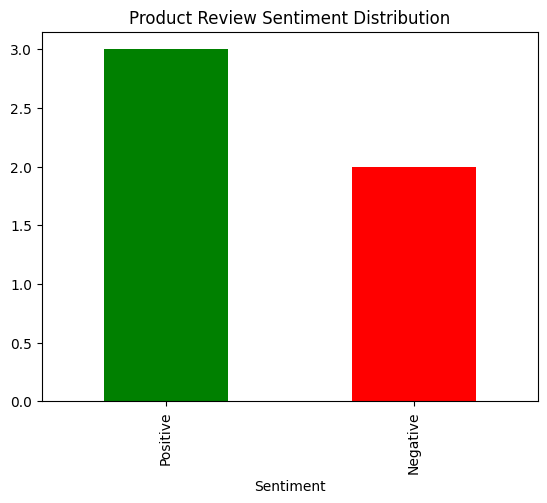

In [3]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

analyzer = SentimentIntensityAnalyzer()

reviews = [
    "Absolutely love this product, it works like a charm!",
    "Worst experience ever. Will never buy again.",
    "It's okay, not great but not bad either.",
    "Very satisfied with the quality!",
    "Disappointed. It stopped working in a week."
]

results = []
for review in reviews:
   
    scores = analyzer.polarity_scores(review)    
    
    if scores['compound'] >= 0.05:
        sentiment = "Positive"
    elif scores['compound'] <= -0.05:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"
        
    results.append({
        "Review": review,
        "Sentiment": sentiment,
        "Compound Score": scores['compound']
    })


df_results = pd.DataFrame(results)
print(df_results)

import matplotlib.pyplot as plt
df_results['Sentiment'].value_counts().plot(kind='bar', color=['green', 'red', 'blue'])
plt.title('Product Review Sentiment Distribution')
plt.show()

# 4. Topic Modeling on Articles using LDA
# Task: Extract 2 topics from a list of article contents.

In [4]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

docs = [
    "Deep learning models can process images and videos.",
    "Neural networks are at the core of deep learning.",
    "Global warming affects the climate and ecosystems.",
    "Carbon emissions cause climate change.",
    "Convolutional neural networks perform well in vision tasks."
]


vectorizer = CountVectorizer(stop_words='english')
doc_term_matrix = vectorizer.fit_transform(docs)

lda = LatentDirichletAllocation(n_components=2, random_state=42)
lda.fit(doc_term_matrix)

words = vectorizer.get_feature_names_out()

for index, topic in enumerate(lda.components_):
    print(f"TOPIC #{index + 1}:")
 
    top_words = [words[i] for i in topic.argsort()[-5:]]
    print(top_words)
    print("-" * 20)

doc_topic_dist = lda.transform(doc_term_matrix)
for i, dist in enumerate(doc_topic_dist):
    topic_num = dist.argmax() + 1
    print(f"Doc {i+1} is likely Topic {topic_num} (Confidence: {dist[topic_num-1]:.2f})")

TOPIC #1:
['vision', 'convolutional', 'perform', 'networks', 'neural']
--------------------
TOPIC #2:
['process', 'models', 'climate', 'learning', 'deep']
--------------------
Doc 1 is likely Topic 2 (Confidence: 0.92)
Doc 2 is likely Topic 1 (Confidence: 0.89)
Doc 3 is likely Topic 1 (Confidence: 0.90)
Doc 4 is likely Topic 2 (Confidence: 0.91)
Doc 5 is likely Topic 1 (Confidence: 0.93)


#  5. Word Cloud for Movie Reviews
# Task: Visualize frequently used words in movie reviews.

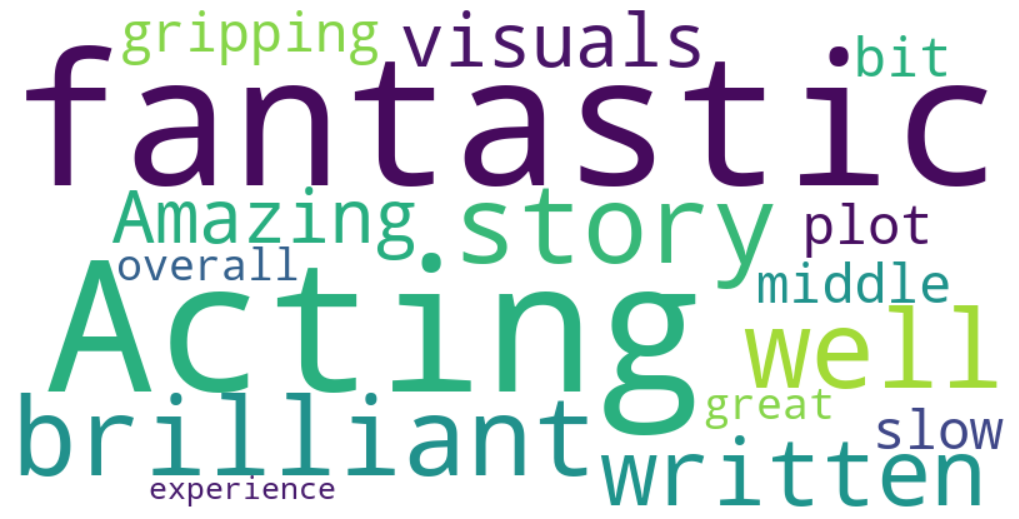

In [5]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

movie_reviews = """
The movie was fantastic! Acting was brilliant and the story was well-written.
Amazing visuals and a gripping plot.
It was a bit slow in the middle, but overall a great movie experience.
"""

stopwords = set(STOPWORDS)
stopwords.update(["movie", "it", "was"]) 

wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    stopwords=stopwords,
    colormap='viridis',  
    min_font_size=10
).generate(movie_reviews)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  
plt.tight_layout(pad=0)
plt.show()